In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.ticker as ticker
plt.rcParams.update({
    'font.size': 7,             # Set global font size
    'font.family': 'Arial',      # Set global font family
    'legend.fontsize': 6,        # Set legend font size
    'figure.figsize': (5.5, 3.5), # Set figure size in inches
    'axes.formatter.limits': (-3, 6),
    'axes.formatter.use_mathtext': True,
})

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000  # Increase the chunk size limit
mpl.rcParams['path.simplify'] = True
mpl.rcParams['path.simplify_threshold'] = 0.5  # Adjust this value if needed
from obspy.core import UTCDateTime

from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import scipy.stats as stats
from scipy.odr import ODR, Model, RealData

In [2]:
df1 = pd.read_csv("../erosion.csv")
df1['Julday'] = df1['Date'].apply(lambda x: UTCDateTime(x).julday)
df1['Year'] = df1['Date'].apply(lambda x: UTCDateTime(x).year)
display(df1.iloc[[6,14],])
df1 = df1.drop([6, 14])
df1.reset_index(drop=True, inplace=True)
df1

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year
6,2020-08-17,8.8693,2.6600,1.2615,835.39,230,2020
14,2022-07-14,-13.2447,-1.8664,-2.5366,2597.17,195,2022


,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year
0,2019-06-21,-5.8157,-1.7500,NaN,3227.68,172,2019
1,2019-07-15,4.6391,0.3300,NaN,860.40,196,2019
2,2019-07-26,-19.8350,-1.6500,NaN,1915.65,207,2019
3,2019-08-11,-6.2511,-0.6900,NaN,2141.46,223,2019
4,2019-08-20,5.4366,-0.2800,NaN,1284.59,232,2019
5,2020-06-29,-3.0450,0.0600,-0.0573,1308.66,181,2020
6,2020-08-30,-10.8239,-6.6600,-6.3241,4768.94,243,2020
7,2021-06-05,-3.8230,-0.7100,2.8336,603.49,156,2021
8,2021-07-06,-6.7797,-1.4000,-0.5915,1736.22,187,2021
9,2021-07-16,5.9832,2.7000,-3.1235,4670.39,197,2021


In [3]:
df1['label'] = [f"{jd}-{str(year)[-2:]}" for jd, year in zip(df1['Julday'], df1['Year'])]

In [4]:
interval_seconds = 5

In [5]:
df2 = pd.read_csv(f"../Figure_6/vol_estimates_{interval_seconds}secs-xLSTM.csv", index_col=0)
# display(df2)
df2 = df2.drop([0, 2, 7, 8, 9, 12, 13, 14, 16, 17, 19, 24])
df2.reset_index(drop=True, inplace=True)
df2['Neg_Err_CIF'] = df2.CIF - df2.CIF_Lower
df2['Pos_Err_CIF'] = df2.CIF_Upper - df2.CIF
df2

,Year,Julian-Day,Volume,Estimated Volume Lower,Estimated Volume,Estimated Volume Upper,CIF,CIF_Lower,CIF_Upper,Uncertainty_Lower,Uncertainty_Upper,Estimated,Absolute_Error,Percent_Error,Neg_Err_CIF,Pos_Err_CIF
0,2019.0,172.0,83123.0,56465.0,65327.0,73043.0,102231.0,95049.0,108096.0,13.57,11.81,No,17796.0,21.41,7182.0,5865.0
1,2019.0,196.0,9869.0,4432.0,5141.0,5639.0,28702.0,26652.0,30060.0,13.79,9.69,No,4728.0,47.91,2050.0,1358.0
2,2019.0,207.0,29077.0,25188.0,28183.0,30634.0,67166.0,63499.0,70023.0,10.63,8.70,Yes,894.0,3.07,3667.0,2857.0
3,2019.0,223.0,70705.0,30186.0,36293.0,41394.0,76213.0,69510.0,81390.0,16.83,14.06,No,34412.0,48.67,6703.0,5177.0
4,2019.0,232.0,21031.0,12215.0,14089.0,15615.0,47500.0,44230.0,50004.0,13.30,10.83,No,6942.0,33.01,3270.0,2504.0
5,2020.0,181.0,6612.0,6019.0,6946.0,7678.0,49930.0,46467.0,52507.0,13.35,10.54,Yes,-334.0,5.05,3463.0,2577.0
6,2020.0,243.0,95823.0,67940.0,81562.0,92631.0,171930.0,156861.0,183272.0,16.70,13.57,No,14261.0,14.88,15069.0,11342.0
7,2021.0,156.0,6127.0,4124.0,5617.0,6914.0,30001.0,25709.0,33283.0,26.58,23.09,Yes,510.0,8.32,4292.0,3282.0
8,2021.0,187.0,76906.0,72911.0,86179.0,97157.0,57706.0,53174.0,61192.0,15.40,12.74,Yes,-9273.0,12.06,4532.0,3486.0
9,2021.0,197.0,80880.0,60005.0,67287.0,73795.0,156103.0,147381.0,163507.0,10.82,9.67,No,13593.0,16.81,8722.0,7404.0


In [6]:
# exclude 2023
# df1 = df1[df1.Year != 2023]
# df2 = df2[df2.Year != 2023]

In [7]:
temp1 = df1[df1.Year == 2023]
temp2 = df2[df2.Year == 2023]

In [8]:
temp1

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year,label
13,2023-06-02,9.6520,5.8903,0.3242,840.96,153,2023,153-23
14,2023-06-10,-1.0175,-0.1026,-1.5559,2073.64,161,2023,161-23
15,2023-07-12,-22.1478,-3.4096,-6.1532,1174.54,193,2023,193-23


In [9]:
temp2

,Year,Julian-Day,Volume,Estimated Volume Lower,Estimated Volume,Estimated Volume Upper,CIF,CIF_Lower,CIF_Upper,Uncertainty_Lower,Uncertainty_Upper,Estimated,Absolute_Error,Percent_Error,Neg_Err_CIF,Pos_Err_CIF
13,2023.0,153.0,4873.0,13803.0,16388.0,18196.0,76825.0,70482.0,80970.0,15.77,11.03,No,-11515.0,236.30,6343.0,4145.0
14,2023.0,161.0,18534.0,23674.0,27698.0,30494.0,99980.0,92403.0,104925.0,14.53,10.09,No,-9164.0,49.44,7577.0,4945.0
15,2023.0,193.0,119088.0,61277.0,71603.0,79480.0,52705.0,48839.0,55466.0,14.42,11.00,No,47485.0,39.87,3866.0,2761.0


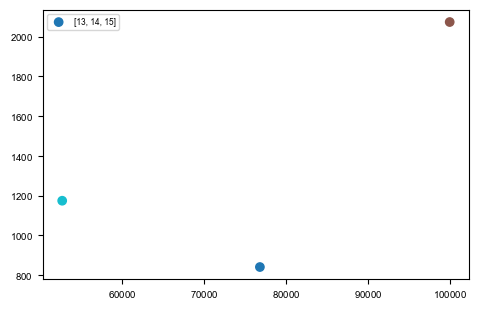

In [10]:
plt.scatter(temp2.CIF, temp1.CFS, c=temp1.index.to_list(), cmap="tab10", label=temp1.index.to_list())
plt.legend()

# Support of erosion correlations with CIF

In [11]:
def linear_function(p, x):
    return p[0] + p[1] * x

In [12]:
len(df1[df1.Year != 2019])

11

Fitted Parameters:
Slope: 1.013654 ± 1.332511
Intercept: -1.655079 ± 6.483116
Log-log R2: 0.8024, log Pearson corr: 0.8973


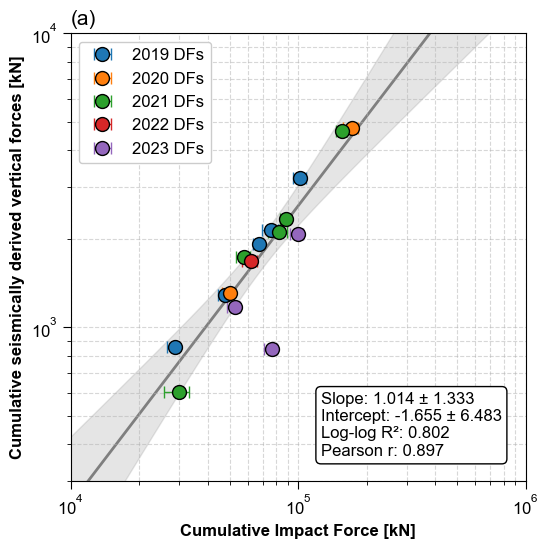

In [23]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
cache_path = "./fig8-cache"
cache = {}
ax.set_yscale("log")
ax.set_xscale("log")
ax.tick_params(axis='both', which='major', labelsize=12, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, length=3)
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,)))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,)))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))
for year, c in zip([2019, 2020, 2021, 2022, 2023], ['C0', 'C1', 'C2', 'C3', 'C4']):
    temp1 = df1[df1.Year == year]
    temp2 = df2[df2.Year == year]
    cache[f'{year}_x'] = temp2.CIF
    cache[f'{year}_y'] = temp1.CFS
    cache[f'{year}_x_err'] = temp2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T 
    ax.errorbar(
        x=temp2.CIF,
        y=temp1.CFS,
        xerr=temp2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
        yerr=None,
        capsize=4,
        ls='none',
        elinewidth=1,
        color=c,
        mfc=c,
        marker="o",
        markeredgecolor="k",
        markersize=10,
        label=f"{year} DFs",
        alpha=1
    )
cache['x'] = df2.CIF.to_numpy()
cache['y'] = df1.CFS.to_numpy()
cache['x_err'] = df2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T
x = df2.CIF.to_numpy()
y = df1.CFS.to_numpy()
xerr = df2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T
yerr = np.zeros_like(y)+1e-13
y_arr = np.array(y)
xerr_1d = np.mean(np.abs(xerr), axis=0)
yerr_1d = np.mean(np.abs(yerr), axis=0)
log_x = np.log10(x)
log_y = np.log10(y_arr)
# convert absolute errors to log-space uncertainties
sx = xerr_1d / (x * np.log(10))
sy = yerr_1d / (y_arr * np.log(10))

data = RealData(log_x, log_y, sx=sx, sy=sy)
model = Model(linear_function)
odr_inst = ODR(data, model, beta0=[0, 1])
output = odr_inst.run()

p_fit = output.beta
p_std = output.sd_beta

x_fit = np.logspace(np.log10(1e4), np.log10(1e6), 100)
log_x_fit = np.log10(x_fit)
log_y_fit = linear_function(p_fit, log_x_fit)
y_fit = 10**log_y_fit

t_val = 1.96
residuals = log_y - linear_function(p_fit, log_x)
residual_std = np.std(residuals, ddof=1)
mean_log_x = np.mean(log_x)
sxx = np.sum((log_x - mean_log_x) ** 2)
y_ci_log = t_val * residual_std * np.sqrt(1 / len(log_x) + (log_x_fit - mean_log_x) ** 2 / sxx)
y_lower = 10 ** (log_y_fit - y_ci_log)
y_upper = 10 ** (log_y_fit + y_ci_log)

ax.set_xlabel("Cumulative Impact Force [kN]", fontsize=12, fontweight="bold")
ax.set_ylabel("Cumulative seismically derived vertical forces [kN]", fontsize=12, fontweight="bold")

# target_slope, target_intercept, _, _, _ = linregress(df2.CIF, df1.CFS)
# print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
# plot_x = np.linspace(0, 8000, 50)
# ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="grey", alpha=1)

ax.plot(x_fit, y_fit, 'k-', linewidth=2, alpha=0.5, zorder=0)
ax.fill_between(x_fit, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)

r2_log = r2_score(log_y, linear_function(p_fit, log_x))
corr_log, _ = stats.pearsonr(log_x, log_y)

info_text = (
    f"Slope: {p_fit[1]:.3f} ± {p_std[1]:.3f}\n"
    f"Intercept: {p_fit[0]:.3f} ± {p_std[0]:.3f}\n"
    f"Log-log R²: {r2_log:.3f}\n"
    f"Pearson r: {corr_log:.3f}"
)
ax.text(0.55, 0.2, info_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=1))



print("Fitted Parameters:")
print(f"Slope: {p_fit[1]:.6f} ± {p_std[1]:.6f}")
print(f"Intercept: {p_fit[0]:.6f} ± {p_std[0]:.6f}")
print(f"Log-log R2: {r2_log:.4f}, log Pearson corr: {corr_log:.4f}")

# cif_scaled = (df2.CIF - df2.CIF.min()) / (df2.CIF.max() - df2.CIF.min())
# cfs_scaled = (df1.CFS - df1.CFS.min()) / (df1.CFS.max() - df1.CFS.min())
# r2 = r2_score(cif_scaled, cfs_scaled)
# corr, _ = stats.pearsonr(df2.CIF, df1.CFS)
# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax.text(0.75, 0.1, info_text, transform=ax.transAxes, fontsize=10,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_ylim(3e2, 1e4)
ax.set_xlim(1e4, 1e6)

leg = ax.legend(loc="best", fontsize=12)
if leg:
    leg.get_frame().set_alpha(1)
ax.grid(True, linestyle="--", alpha=0.5, which='both')
os.makedirs(cache_path, exist_ok=True)
np.savez(f"{cache_path}/fig1.npz", **cache)
ax.set_title("(a)", loc="left", fontsize=15)
fig.tight_layout()
# fig.savefig(f"CFS-CIF_Corr_w2023_{interval_seconds}.png", dpi=600, transparent=False)

# xLSTM CIF Diff and Erosion realation

In [21]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, MultipleLocator

import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import scipy.stats as stats


from tqdm import tqdm

import sys
sys.path.append('../')
from functions.data_processing.read_data import load_label
from functions.utils import *

In [22]:
def edit_ax(ax, lab):
    if lab == 1:
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.xaxis.set_minor_locator(MultipleLocator(100))
        ax.xaxis.set_major_locator(MultipleLocator(500))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(5))
        ax.tick_params(axis='both', which='major', labelsize=8, length=6)
        ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
        ax.set_xticks(range(0, 8000+1, 500))
        ax.set_yticks(range(-25, 10+1, 5))

        ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=10,fontweight="bold")
        ax.set_ylabel('Local reach change (m³/m)', fontsize=10,fontweight="bold")
        ax.set_xlim(0, 8000)
        ax.set_ylim(-25, 12)
        ax.axhspan(0, 12, facecolor='green', alpha=0.05)
        ax.axhspan(-25, 0, facecolor='red', alpha=0.05)
    elif lab == 2:
        # ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        # ax.xaxis.set_minor_locator(MultipleLocator(100))
        # ax.xaxis.set_major_locator(MultipleLocator(500))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(2))
        ax.tick_params(axis='both', which='major', labelsize=8, length=6)
        ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
        # ax.set_xticks(range(0, 8000+1, 500))
        ax.set_yticks(range(-8, 8+1, 2))

        ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=10,fontweight="bold")
        ax.set_ylabel('Downstream reach change (m³/m)', fontsize=10,fontweight="bold")
        ax.set_xlim(0, 8000)
        ax.set_ylim(-8, 8)
        ax.axhspan(0, 8, facecolor='green', alpha=0.05)
        ax.axhspan(-8, 0, facecolor='red', alpha=0.05)
    elif lab == 3:
        # ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        # ax.xaxis.set_minor_locator(MultipleLocator(100))
        # ax.xaxis.set_major_locator(MultipleLocator(500))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(2))
        ax.tick_params(axis='both', which='major', labelsize=8, length=6)
        ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
        # ax.set_xticks(range(0, 8000+1, 500))
        ax.set_yticks(range(-8, 5+1, 2))

        ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=10,fontweight="bold")
        ax.set_ylabel('Long reach change (m³/m)', fontsize=10,fontweight="bold")
        ax.set_xlim(0, 8000)
        ax.set_ylim(-8, 5)
        ax.axhspan(0, 5, facecolor='green', alpha=0.05)
        ax.axhspan(-8, 0, facecolor='red', alpha=0.05)

    return None

In [23]:
import json
with open("../config/event_id_map.json", "r") as f:
    event_id_map = json.load(f)
test_dir = "../comparison2_v2/model_test"
thres = 2

In [24]:
ill12_dir = f"{test_dir}3/ILL12"
ill11_dir = f"{test_dir}/ILL11"
print(ill12_dir)
print(ill11_dir)

interval = 5
diff_list_2019 = []
results_2019_ILL11 = {}
results_2019_ILL12 = {}
prediction_csums_ILL11 = []
prediction_csums_ILL12 = []
year = 2019
juldays = [172, 196, 207, 223, 232]
julday_list_2019 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
for event_id, julday in zip(["3", "6", "7", "8", "9"], juldays):
    component = "EHZ"
    network = "9S"
    # test_dir = "../model_test"
    model = "xLSTM"
    interval_seconds = interval
    # Load ILL12 data
    station = "ILL12"
    # st1 = load_seismic_data_test(julday= int(julday), station= station, year= year, component= component, network= network)
    df_dir = f"{test_dir}/{station}/{model}_{interval_seconds}/{year}/df"
    df1 = pd.read_csv(f"{df_dir}/{julday}.csv", index_col=False)
    # Load ILL11 data
    station = "ILL11"
    # st2 = load_seismic_data_test(julday= int(julday), station= station, year= year, component= component, network= network)
    df_dir = f"{test_dir}/{station}/{model}_{interval_seconds}/{year}/df"
    df2 = pd.read_csv(f"{df_dir}/{julday}.csv", index_col=False)

    df1['Timestamps'] = df1['Timestamps'].apply(lambda x: UTCDateTime(x))
    df2['Timestamps'] = df2['Timestamps'].apply(lambda x: UTCDateTime(x))
    df1 = df1[df1.Timestamps.between(UTCDateTime(event_id_map[event_id]['start_time']) - 3600, UTCDateTime(event_id_map[event_id]['end_time']) + 3600)]
    df2 = df2[df2.Timestamps.between(UTCDateTime(event_id_map[event_id]['start_time']) - 3600, UTCDateTime(event_id_map[event_id]['end_time']) + 3600)]
    temp = df2[df2['Predicted_Output_Mean'] > thres]
    prediction_csums_ILL11.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    
    temp = df1[df1['Predicted_Output_Mean'] > thres]
    prediction_csums_ILL12.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    
    csum1 = df1[df1["Predicted_Output_Mean"] > thres]['Predicted_Output_Mean'].sum()
    csum2 = df2[df2["Predicted_Output_Mean"] > thres]['Predicted_Output_Mean'].sum()
    diff = csum2 - csum1
    diff_list_2019.append(diff)

prediction_csums = np.array(prediction_csums_ILL11)
results_2019_ILL11[model] = prediction_csums
prediction_csums = np.array(prediction_csums_ILL12)
results_2019_ILL12[model] = prediction_csums

# 2020
year = 2020
juldays = [156, 160, 169, 181, 243]
start_times = ["2020-06-04 15:00:00", "2020-06-08 15:00:00", "2020-06-17 03:00:00", "2020-06-29 04:30:00", "2020-08-30 05:00:00"] # "2020-06-07 09:00:00"
end_times = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"
julday_list_2020_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2020_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{ill11_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2020_ILL11[model] = prediction_csums
year = 2020
juldays = [156, 160, 169, 181, 243]
start_times = ["2020-06-04 15:00:00", "2020-06-08 13:00:00", "2020-06-17 01:00:00", "2020-06-29 03:30:00", "2020-08-30 04:00:00"] # "2020-06-07 09:00:00"
end_times = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"
julday_list_2020_12 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2020_ILL12 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{ill12_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2020_ILL12[model] = prediction_csums
# 2021
year = 2021
juldays = [131, 136, 142, 156, 173, 175, 187, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 14:30:00", "2021-07-06 18:00:00",
            "2021-07-16 03:00:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]
julday_list_2021_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2021_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        if julday == 142:
            df1 = pd.read_csv(f"{ill11_dir}/{model}_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            df2 = pd.read_csv(f"{ill11_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{ill11_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2021_ILL11[model] = prediction_csums
year = 2021
juldays = [173, 175, 187, 197, 262]
start_times = ["2021-06-22 19:00:00", "2021-06-24 14:30:00", "2021-07-06 18:00:00",
            "2021-07-16 03:00:00", "2021-09-19 05:30:00"]
end_times = ["2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00",
            "2021-07-16 08:00:00", "2021-09-19 12:30:00"]
julday_list_2021_12 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2021_ILL12 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        if julday == 142:
            df1 = pd.read_csv(f"{ill12_dir}/{model}_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            df2 = pd.read_csv(f"{ill12_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{ill12_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2021_ILL12[model] = prediction_csums
# 2022
year = 2022
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
julday_list_2022_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2022_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{ill11_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2022_ILL11[model] = prediction_csums
year = 2022
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
julday_list_2022_12 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2022_ILL12 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{ill12_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2022_ILL12[model] = prediction_csums
# 2023
year = 2023
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
end_times = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]
julday_list_2023_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2023_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{ill11_dir}/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2023_ILL11[model] = prediction_csums

../comparison2_v2/model_test3/ILL12
../comparison2_v2/model_test/ILL11


100%|██████████| 3/3 [00:01<00:00,  1.91it/s]


In [25]:
df1 = pd.read_csv("erosion.csv")
df1['Julday'] = df1['Date'].apply(lambda x: UTCDateTime(x).julday)
df1['Year'] = df1['Date'].apply(lambda x: UTCDateTime(x).year)
df1 = df1.drop([6, 14])
df1.reset_index(drop=True, inplace=True)
df1.head()

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year
0,2019-06-21,-5.8157,-1.75,NaN,3227.68,172,2019
1,2019-07-15,4.6391,0.33,NaN,860.40,196,2019
2,2019-07-26,-19.8350,-1.65,NaN,1915.65,207,2019
3,2019-08-11,-6.2511,-0.69,NaN,2141.46,223,2019
4,2019-08-20,5.4366,-0.28,NaN,1284.59,232,2019


In [26]:
ILL12_2019 = results_2019_ILL12['xLSTM']
ILL12_2020 = results_2020_ILL12['xLSTM'][[3,4],:]
ILL12_2021 = results_2021_ILL12['xLSTM']
ILL12_2022 = results_2022_ILL12['xLSTM']

In [27]:
# a11, a12 = results_2019_ILL11['xLSTM'][:,0], results_2019_ILL12['xLSTM'][:,0]
# b11, b12 = results_2019_ILL11['xLSTM'][:,1], results_2019_ILL12['xLSTM'][:,1]
# c11, c12 = results_2019_ILL11['xLSTM'][:,2], results_2019_ILL12['xLSTM'][:,2]
# diff_nerr_2019 = (((a11 - b11) + (a12 - b12)) // 2).reshape(1,-1)
# diff_perr_2019 = (((c11 - a11) + (c12 - a12)) // 2).reshape(1,-1)


# a11, a12 = results_2020_ILL11['xLSTM'][[3,4],0], results_2020_ILL12['xLSTM'][[3,4],0]
# b11, b12 = results_2020_ILL11['xLSTM'][[3,4],1], results_2020_ILL12['xLSTM'][[3,4],1]
# c11, c12 = results_2020_ILL11['xLSTM'][[3,4],2], results_2020_ILL12['xLSTM'][[3,4],2]
# diff_nerr_2020 = (((a11 - b11) + (a12 - b12)) // 2).reshape(1,-1)
# diff_perr_2020 = (((c11 - a11) + (c12 - a12)) // 2).reshape(1,-1)

# a11, a12 = results_2021_ILL11['xLSTM'][[4,5,6,7,9],0], results_2021_ILL12['xLSTM'][:,0]
# b11, b12 = results_2021_ILL11['xLSTM'][[4,5,6,7,9],1], results_2021_ILL12['xLSTM'][:,1]
# c11, c12 = results_2021_ILL11['xLSTM'][[4,5,6,7,9],2], results_2021_ILL12['xLSTM'][:,2]
# diff_nerr_2021 = (((a11 - b11) + (a12 - b12)) // 2).reshape(1,-1)
# diff_perr_2021 = (((c11 - a11) + (c12 - a12)) // 2).reshape(1,-1)

# a11, a12 = results_2022_ILL11['xLSTM'][:,0], results_2022_ILL12['xLSTM'][:,0]
# b11, b12 = results_2022_ILL11['xLSTM'][:,1], results_2022_ILL12['xLSTM'][:,1]
# c11, c12 = results_2022_ILL11['xLSTM'][:,2], results_2022_ILL12['xLSTM'][:,2]
# diff_nerr_2022 = (((a11 - b11) + (a12 - b12)) // 2).reshape(1,-1)
# diff_perr_2022 = (((c11 - a11) + (c12 - a12)) // 2).reshape(1,-1)

In [33]:
(ILL12_2022[[0],2] - ILL12_2022[[0],0]).reshape(1,-1)
(ILL12_2022[[0],0] - ILL12_2022[[0],1]).reshape(1,-1)

array([[528.18609483]])

2019
2020
2021
2022


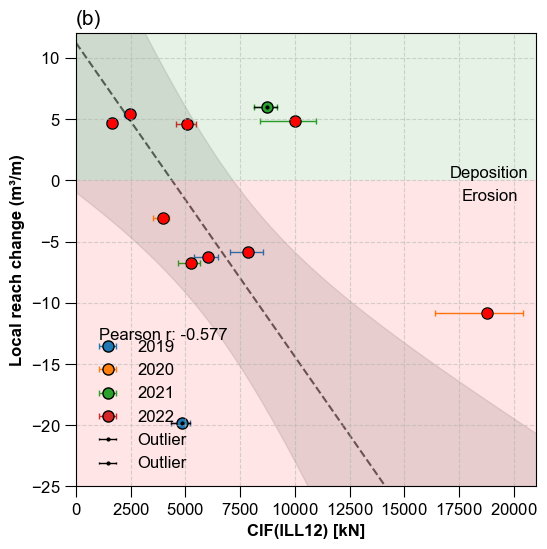

In [64]:
years_data = {
    2019: dict(
        x=ILL12_2019[:,0],
        y=df1[df1.Year == 2019]['Erosion1'].values,
        xerr=np.concatenate([(ILL12_2019[:,0] - ILL12_2019[:,1]).reshape(1,-1), (ILL12_2019[:,2] - ILL12_2019[:,0]).reshape(1,-1)]),
        color="C0",
    ),
    2020: dict(
        x=ILL12_2020[:,0],
        y=df1[df1.Year == 2020]['Erosion1'].values,
        xerr=np.concatenate([(ILL12_2020[:,0] - ILL12_2020[:,1]).reshape(1,-1), (ILL12_2020[:,2] - ILL12_2020[:,0]).reshape(1,-1)]),
        color="C1",
    ),
    2021: dict(
        x=ILL12_2021[[2, 3, 4],0],
        y=df1[df1.Year == 2021].iloc[[1, 2, 4]]['Erosion1'].values,
        xerr=np.concatenate([(ILL12_2021[[2, 3, 4],0] - ILL12_2021[[2, 3, 4],1]).reshape(1,-1), (ILL12_2021[[2, 3, 4],2] - ILL12_2021[[2, 3, 4],0]).reshape(1,-1)]),
        color="C2",
    ),
    2022: dict(
        x=ILL12_2022[:1,0],
        y=df1[df1.Year == 2022]['Erosion1'].values,
        xerr=np.concatenate([(ILL12_2022[[0],0] - ILL12_2022[[0],1]).reshape(1,-1), (ILL12_2022[[0],2] - ILL12_2022[[0],0]).reshape(1,-1)]),
        color="C3",
    ),
}

fig, ax = plt.subplots(figsize=(5.5, 5.5))

errorbar_kwargs = dict(
    yerr=None, capsize=2, ls='none', elinewidth=1,
    marker="o", markersize=8, zorder=1, markeredgecolor="k",
)

for year, d in years_data.items():
    print(year)
    ax.errorbar(
        x=d["x"], y=d["y"], xerr=d["xerr"],
        color=d["color"], mfc=d["color"], label=str(year),
        **errorbar_kwargs,
    )

# Julian day labels per year (kept for reference / future annotation use)
labs = np.concatenate([
    np.array(julday_list_2019),
    np.array(julday_list_2020_12)[-2:],
    np.array(julday_list_2021_12)[[2, 3, 4]],
    np.array(julday_list_2022_12)[0:1],
])

# Combined arrays across all years
x = np.concatenate([d["x"] for d in years_data.values()])
y = np.concatenate([d["y"] for d in years_data.values()])
x_err = np.concatenate([d["xerr"] for d in years_data.values()], axis=1)

# Outlier point, highlighted separately
ax.errorbar(
    x=years_data[2019]["x"][2:3],
    y=years_data[2019]["y"][2:3],
    xerr=years_data[2019]["xerr"][:, 2:3],
    yerr=None, capsize=1, ls='none', elinewidth=1,
    color="k", mfc="k", marker="o", markersize=2,
    label="Outlier", zorder=1, markeredgecolor="k",
)


ax.errorbar(
    x=years_data[2021]["x"][1:2],
    y=years_data[2021]["y"][1:2],
    xerr=years_data[2021]["xerr"][:, 1:2],
    yerr=None, capsize=1, ls='none', elinewidth=1,
    color="k", mfc="k", marker="o", markersize=2,
    label="Outlier", zorder=1, markeredgecolor="k",
)

# ------------------------------------------------------------------
# ODR linear fit on the selected (non-outlier) subset
# ------------------------------------------------------------------
sel_idx = [0,1,3,4,5,6,7,9,10]
sel_x, sel_y = x[sel_idx], y[sel_idx]
sel_x_err_mean = x_err[:, sel_idx].mean(axis=0)

plt.plot(sel_x, sel_y, "ro")
def linear_func(beta, x):
    return beta[0] * x + beta[1]

data = RealData(sel_x, sel_y, sx=sel_x_err_mean)
model = Model(linear_func)
odr_inst = ODR(data, model, beta0=[-0.002, 3.0])
output = odr_inst.run()

slope, intercept = output.beta
slope_err, intercept_err = output.sd_beta

# Prediction line + 95% confidence interval
plot_x = np.linspace(0, 22000, 100)
y_pred = slope * plot_x + intercept

residuals = sel_y - (slope * sel_x + intercept)
residual_std = np.std(residuals, ddof=1)
mean_sel_x = np.mean(sel_x)
sxx = np.sum((sel_x - mean_sel_x) ** 2)
t_val = 1.96

y_ci = t_val * residual_std * np.sqrt(1 / len(sel_x) + (plot_x - mean_sel_x) ** 2 / sxx)
y_lower, y_upper = y_pred - y_ci, y_pred + y_ci

ax.fill_between(plot_x, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)
ax.plot(plot_x, y_pred, linestyle="--", color="k", alpha=0.6, zorder=0)

# Fit quality metrics
r2 = r2_score(sel_y, linear_func([slope, intercept], sel_x))
corr, _ = stats.pearsonr(sel_x, sel_y)

# ------------------------------------------------------------------
# Annotations
# ------------------------------------------------------------------
ax.text(0.05, 0.35, f"Pearson r: {corr:.3f}", transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.text(0.9, 0.69, "Deposition", ha="center", va="center", transform=ax.transAxes, fontsize=12)
ax.text(0.9, 0.64, "Erosion", ha="center", va="center", transform=ax.transAxes, fontsize=12)

# ------------------------------------------------------------------
# Styling
# ------------------------------------------------------------------
leg = ax.legend(loc="lower left", fontsize=12)
if leg:
    leg.get_frame().set_alpha(0)

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("CIF(ILL12) [kN]", fontsize=12, fontweight="bold")
ax.set_ylabel('Local reach change (m³/m)', fontsize=12, fontweight="bold")
ax.tick_params(axis='both', which='major', labelsize=12, length=8)
ax.set_ylim(-25, 12)
ax.set_xlim(0, 21000)
ax.axhspan(0, 12, facecolor='green', alpha=0.1)
ax.axhspan(-25, 0, facecolor='red', alpha=0.1)
ax.set_title("(b)", loc="left", fontsize=15)

fig.tight_layout()
# fig.savefig(f"./output_images27/CIF-Diff-Erosion2-{interval_seconds}.png", dpi=600)

In [ ]:
[0, 1, 3, 4,5,6,7,9,10]

array([ 7873.54686259,  1659.33279776,  6034.96325457,  2473.30331601,
        3954.02408919, 18792.63629093,  5248.41653064,  8740.61738696,
        5087.60843893])

In [60]:
x

array([ 7873.54686259,  1659.33279776,  4836.16935077,  6034.96325457,
        2473.30331601,  3954.02408919, 18792.63629093,  5248.41653064,
        8740.61738696, 10008.93502981,  5087.60843893])

2019
2020
2021
2022


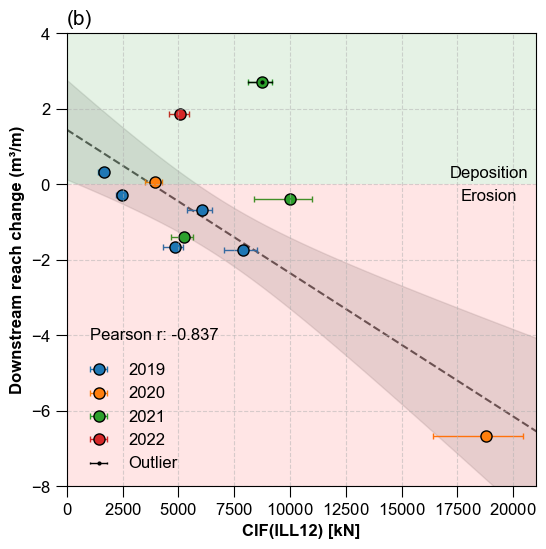

In [43]:
years_data = {
    2019: dict(
        x=ILL12_2019[:,0],
        y=df1[df1.Year == 2019]['Erosion2'].values,
        xerr=np.concatenate([(ILL12_2019[:,0] - ILL12_2019[:,1]).reshape(1,-1), (ILL12_2019[:,2] - ILL12_2019[:,0]).reshape(1,-1)]),
        color="C0",
    ),
    2020: dict(
        x=ILL12_2020[:,0],
        y=df1[df1.Year == 2020]['Erosion2'].values,
        xerr=np.concatenate([(ILL12_2020[:,0] - ILL12_2020[:,1]).reshape(1,-1), (ILL12_2020[:,2] - ILL12_2020[:,0]).reshape(1,-1)]),
        color="C1",
    ),
    2021: dict(
        x=ILL12_2021[[2, 3, 4],0],
        y=df1[df1.Year == 2021].iloc[[1, 2, 4]]['Erosion2'].values,
        xerr=np.concatenate([(ILL12_2021[[2, 3, 4],0] - ILL12_2021[[2, 3, 4],1]).reshape(1,-1), (ILL12_2021[[2, 3, 4],2] - ILL12_2021[[2, 3, 4],0]).reshape(1,-1)]),
        color="C2",
    ),
    2022: dict(
        x=ILL12_2022[:1,0],
        y=df1[df1.Year == 2022]['Erosion2'].values,
        xerr=np.concatenate([(ILL12_2022[[0],0] - ILL12_2022[[0],1]).reshape(1,-1), (ILL12_2022[[0],2] - ILL12_2022[[0],0]).reshape(1,-1)]),
        color="C3",
    ),
}

fig, ax = plt.subplots(figsize=(5.5, 5.5))

errorbar_kwargs = dict(
    yerr=None, capsize=2, ls='none', elinewidth=1,
    marker="o", markersize=8, zorder=1, markeredgecolor="k",
)

for year, d in years_data.items():
    print(year)
    ax.errorbar(
        x=d["x"], y=d["y"], xerr=d["xerr"],
        color=d["color"], mfc=d["color"], label=str(year),
        **errorbar_kwargs,
    )

# Julian day labels per year (kept for reference / future annotation use)
labs = np.concatenate([
    np.array(julday_list_2019),
    np.array(julday_list_2020_12)[-2:],
    np.array(julday_list_2021_12)[[2, 3, 4]],
    np.array(julday_list_2022_12)[0:1],
])

# Combined arrays across all years
x = np.concatenate([d["x"] for d in years_data.values()])
y = np.concatenate([d["y"] for d in years_data.values()])
x_err = np.concatenate([d["xerr"] for d in years_data.values()], axis=1)

# Outlier point, highlighted separately
ax.errorbar(
    x=years_data[2021]["x"][1:2],
    y=years_data[2021]["y"][1:2],
    xerr=years_data[2021]["xerr"][:, 1:2],
    yerr=None, capsize=1, ls='none', elinewidth=1,
    color="k", mfc="k", marker="o", markersize=2,
    label="Outlier", zorder=1, markeredgecolor="k",
)

# ------------------------------------------------------------------
# ODR linear fit on the selected (non-outlier) subset
# ------------------------------------------------------------------
sel_idx = [0, 1, 2, 3, 4, 5, 6, 7, 9, 10]
sel_x, sel_y = x[sel_idx], y[sel_idx]
sel_x_err_mean = x_err[:, sel_idx].mean(axis=0)

def linear_func(beta, x):
    return beta[0] * x + beta[1]

data = RealData(sel_x, sel_y, sx=sel_x_err_mean)
model = Model(linear_func)
odr_inst = ODR(data, model, beta0=[-0.002, 3.0])
output = odr_inst.run()

slope, intercept = output.beta
slope_err, intercept_err = output.sd_beta

# Prediction line + 95% confidence interval
plot_x = np.linspace(0, 22000, 100)
y_pred = slope * plot_x + intercept

residuals = sel_y - (slope * sel_x + intercept)
residual_std = np.std(residuals, ddof=1)
mean_sel_x = np.mean(sel_x)
sxx = np.sum((sel_x - mean_sel_x) ** 2)
t_val = 1.96

y_ci = t_val * residual_std * np.sqrt(1 / len(sel_x) + (plot_x - mean_sel_x) ** 2 / sxx)
y_lower, y_upper = y_pred - y_ci, y_pred + y_ci

ax.fill_between(plot_x, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)
ax.plot(plot_x, y_pred, linestyle="--", color="k", alpha=0.6, zorder=0)

# Fit quality metrics
r2 = r2_score(sel_y, linear_func([slope, intercept], sel_x))
corr, _ = stats.pearsonr(sel_x, sel_y)

# ------------------------------------------------------------------
# Annotations
# ------------------------------------------------------------------
ax.text(0.05, 0.35, f"Pearson r: {corr:.3f}", transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.text(0.9, 0.69, "Deposition", ha="center", va="center", transform=ax.transAxes, fontsize=12)
ax.text(0.9, 0.64, "Erosion", ha="center", va="center", transform=ax.transAxes, fontsize=12)

# ------------------------------------------------------------------
# Styling
# ------------------------------------------------------------------
leg = ax.legend(loc="lower left", fontsize=12)
if leg:
    leg.get_frame().set_alpha(0)

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("CIF(ILL12) [kN]", fontsize=12, fontweight="bold")
ax.set_ylabel('Downstream reach change (m³/m)', fontsize=12, fontweight="bold")
ax.tick_params(axis='both', which='major', labelsize=12, length=8)
ax.set_ylim(-8, 4)
ax.set_xlim(0, 21000)
ax.axhspan(0, 8, facecolor='green', alpha=0.1)
ax.axhspan(-8, 0, facecolor='red', alpha=0.1)
ax.set_title("(b)", loc="left", fontsize=15)

fig.tight_layout()
# fig.savefig(f"./output_images27/CIF-Diff-Erosion2-{interval_seconds}.png", dpi=600)

2020
2021
2022


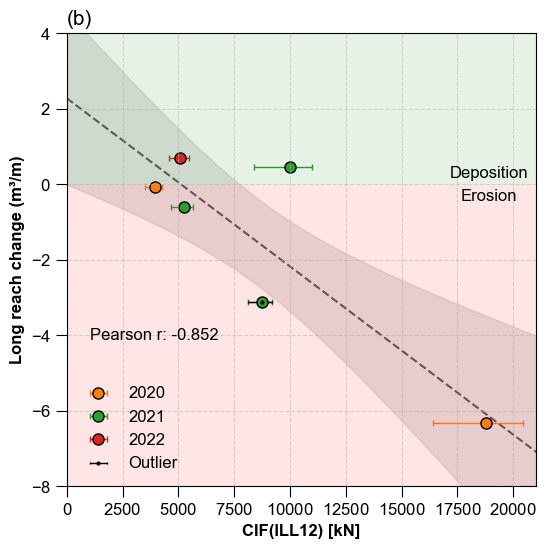

In [66]:
years_data = {
    # 2019: dict(
    #     x=ILL12_2019[:,0],
    #     y=df1[df1.Year == 2019]['Erosion3'].values,
    #     xerr=np.concatenate([(ILL12_2019[:,0] - ILL12_2019[:,1]).reshape(1,-1), (ILL12_2019[:,2] - ILL12_2019[:,0]).reshape(1,-1)]),
    #     color="C0",
    # ),
    2020: dict(
        x=ILL12_2020[:,0],
        y=df1[df1.Year == 2020]['Erosion3'].values,
        xerr=np.concatenate([(ILL12_2020[:,0] - ILL12_2020[:,1]).reshape(1,-1), (ILL12_2020[:,2] - ILL12_2020[:,0]).reshape(1,-1)]),
        color="C1",
    ),
    2021: dict(
        x=ILL12_2021[[2, 3, 4],0],
        y=df1[df1.Year == 2021].iloc[[1, 2, 4]]['Erosion3'].values,
        xerr=np.concatenate([(ILL12_2021[[2, 3, 4],0] - ILL12_2021[[2, 3, 4],1]).reshape(1,-1), (ILL12_2021[[2, 3, 4],2] - ILL12_2021[[2, 3, 4],0]).reshape(1,-1)]),
        color="C2",
    ),
    2022: dict(
        x=ILL12_2022[:1,0],
        y=df1[df1.Year == 2022]['Erosion3'].values,
        xerr=np.concatenate([(ILL12_2022[[0],0] - ILL12_2022[[0],1]).reshape(1,-1), (ILL12_2022[[0],2] - ILL12_2022[[0],0]).reshape(1,-1)]),
        color="C3",
    ),
}

fig, ax = plt.subplots(figsize=(5.5, 5.5))

errorbar_kwargs = dict(
    yerr=None, capsize=2, ls='none', elinewidth=1,
    marker="o", markersize=8, zorder=1, markeredgecolor="k",
)

for year, d in years_data.items():
    print(year)
    ax.errorbar(
        x=d["x"], y=d["y"], xerr=d["xerr"],
        color=d["color"], mfc=d["color"], label=str(year),
        **errorbar_kwargs,
    )

# Julian day labels per year (kept for reference / future annotation use)
labs = np.concatenate([
    np.array(julday_list_2019),
    np.array(julday_list_2020_12)[-2:],
    np.array(julday_list_2021_12)[[2, 3, 4]],
    np.array(julday_list_2022_12)[0:1],
])

# Combined arrays across all years
x = np.concatenate([d["x"] for d in years_data.values()])
y = np.concatenate([d["y"] for d in years_data.values()])
x_err = np.concatenate([d["xerr"] for d in years_data.values()], axis=1)

# Outlier point, highlighted separately
ax.errorbar(
    x=years_data[2021]["x"][1:2],
    y=years_data[2021]["y"][1:2],
    xerr=years_data[2021]["xerr"][:, 1:2],
    yerr=None, capsize=1, ls='none', elinewidth=1,
    color="k", mfc="k", marker="o", markersize=2,
    label="Outlier", zorder=1, markeredgecolor="k",
)

# ------------------------------------------------------------------
# ODR linear fit on the selected (non-outlier) subset
# ------------------------------------------------------------------
sel_idx = [0, 1, 2, 3, 4, 5]
sel_x, sel_y = x[sel_idx], y[sel_idx]
sel_x_err_mean = x_err[:, sel_idx].mean(axis=0)

def linear_func(beta, x):
    return beta[0] * x + beta[1]

data = RealData(sel_x, sel_y, sx=sel_x_err_mean)
model = Model(linear_func)
odr_inst = ODR(data, model, beta0=[-0.002, 3.0])
output = odr_inst.run()

slope, intercept = output.beta
slope_err, intercept_err = output.sd_beta

# Prediction line + 95% confidence interval
plot_x = np.linspace(0, 22000, 100)
y_pred = slope * plot_x + intercept

residuals = sel_y - (slope * sel_x + intercept)
residual_std = np.std(residuals, ddof=1)
mean_sel_x = np.mean(sel_x)
sxx = np.sum((sel_x - mean_sel_x) ** 2)
t_val = 1.96

y_ci = t_val * residual_std * np.sqrt(1 / len(sel_x) + (plot_x - mean_sel_x) ** 2 / sxx)
y_lower, y_upper = y_pred - y_ci, y_pred + y_ci

ax.fill_between(plot_x, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)
ax.plot(plot_x, y_pred, linestyle="--", color="k", alpha=0.6, zorder=0)

# Fit quality metrics
r2 = r2_score(sel_y, linear_func([slope, intercept], sel_x))
corr, _ = stats.pearsonr(sel_x, sel_y)

# ------------------------------------------------------------------
# Annotations
# ------------------------------------------------------------------
ax.text(0.05, 0.35, f"Pearson r: {corr:.3f}", transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.text(0.9, 0.69, "Deposition", ha="center", va="center", transform=ax.transAxes, fontsize=12)
ax.text(0.9, 0.64, "Erosion", ha="center", va="center", transform=ax.transAxes, fontsize=12)

# ------------------------------------------------------------------
# Styling
# ------------------------------------------------------------------
leg = ax.legend(loc="lower left", fontsize=12)
if leg:
    leg.get_frame().set_alpha(0)

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("CIF(ILL12) [kN]", fontsize=12, fontweight="bold")
ax.set_ylabel('Long reach change (m³/m)', fontsize=12, fontweight="bold")
ax.tick_params(axis='both', which='major', labelsize=12, length=8)
ax.set_ylim(-8, 4)
ax.set_xlim(0, 21000)
ax.axhspan(0, 8, facecolor='green', alpha=0.1)
ax.axhspan(-8, 0, facecolor='red', alpha=0.1)
ax.set_title("(b)", loc="left", fontsize=15)

fig.tight_layout()
# fig.savefig(f"./output_images27/CIF-Diff-Erosion2-{interval_seconds}.png", dpi=600)

In [17]:
df2 = pd.read_csv(f"../Figure_6/vol_estimates_{interval_seconds}secs-xLSTM.csv", index_col=0)
# display(df2)
df2 = df2.drop([0, 2, 7, 8, 9, 12, 13, 14, 16, 17, 19, 24])
df2.reset_index(drop=True, inplace=True)
df2['Neg_Err_CIF'] = df2.CIF - df2.CIF_Lower
df2['Pos_Err_CIF'] = df2.CIF_Upper - df2.CIF
df2

,Year,Julian-Day,Volume,Estimated Volume Lower,Estimated Volume,Estimated Volume Upper,CIF,CIF_Lower,CIF_Upper,Uncertainty_Lower,Uncertainty_Upper,Estimated,Absolute_Error,Percent_Error,Neg_Err_CIF,Pos_Err_CIF
0,2019.0,172.0,83123.0,56465.0,65327.0,73043.0,102231.0,95049.0,108096.0,13.57,11.81,No,17796.0,21.41,7182.0,5865.0
1,2019.0,196.0,9869.0,4432.0,5141.0,5639.0,28702.0,26652.0,30060.0,13.79,9.69,No,4728.0,47.91,2050.0,1358.0
2,2019.0,207.0,29077.0,25188.0,28183.0,30634.0,67166.0,63499.0,70023.0,10.63,8.70,Yes,894.0,3.07,3667.0,2857.0
3,2019.0,223.0,70705.0,30186.0,36293.0,41394.0,76213.0,69510.0,81390.0,16.83,14.06,No,34412.0,48.67,6703.0,5177.0
4,2019.0,232.0,21031.0,12215.0,14089.0,15615.0,47500.0,44230.0,50004.0,13.30,10.83,No,6942.0,33.01,3270.0,2504.0
5,2020.0,181.0,6612.0,6019.0,6946.0,7678.0,49930.0,46467.0,52507.0,13.35,10.54,Yes,-334.0,5.05,3463.0,2577.0
6,2020.0,243.0,95823.0,67940.0,81562.0,92631.0,171930.0,156861.0,183272.0,16.70,13.57,No,14261.0,14.88,15069.0,11342.0
7,2021.0,156.0,6127.0,4124.0,5617.0,6914.0,30001.0,25709.0,33283.0,26.58,23.09,Yes,510.0,8.32,4292.0,3282.0
8,2021.0,187.0,76906.0,72911.0,86179.0,97157.0,57706.0,53174.0,61192.0,15.40,12.74,Yes,-9273.0,12.06,4532.0,3486.0
9,2021.0,197.0,80880.0,60005.0,67287.0,73795.0,156103.0,147381.0,163507.0,10.82,9.67,No,13593.0,16.81,8722.0,7404.0


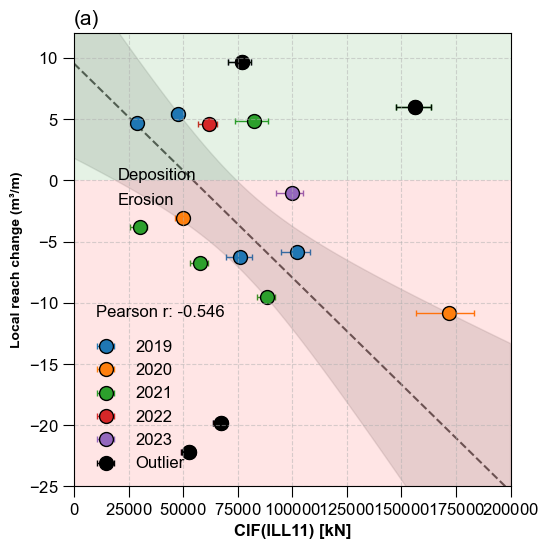

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

x_2019, y_2019 = df2.iloc[0:5]['CIF'].values, df1[df1.Year == 2019]['Erosion1'].values
x_err_2019 = df2.iloc[0:5][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2020, y_2020 = df2.iloc[5:7]['CIF'].values, df1[df1.Year == 2020]['Erosion1'].values
x_err_2020 = df2.iloc[5:7][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2021, y_2021 = df2.iloc[7:12]['CIF'].values, df1[df1.Year == 2021]['Erosion1'].values
x_err_2021 = df2.iloc[7:12][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2022, y_2022 = df2.iloc[12:13]['CIF'].values, df1[df1.Year == 2022]['Erosion1'].values
x_err_2022 = df2.iloc[12:13][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2023, y_2023 = df2.iloc[13:]['CIF'].values, df1[df1.Year == 2023]['Erosion1'].values
x_err_2023 = df2.iloc[13:][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T

ax.errorbar(
    x=x_2019,
    y=y_2019,
    xerr=x_err_2019,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C0",
    mfc="C0",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2019",
    zorder=1
)
ax.errorbar(
    x=x_2020,
    y=y_2020,
    xerr=x_err_2020,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C1",
    mfc="C1",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2020",
    zorder=1
)
ax.errorbar(
    x=x_2021,
    y=y_2021,
    xerr=x_err_2021,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C2",
    mfc="C2",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2021",
    zorder=1
)
ax.errorbar(
    x=x_2022,
    y=y_2022,
    xerr=x_err_2022,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C3",
    mfc="C3",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2022",
    zorder=1
)
ax.errorbar(
    x=x_2023,
    y=y_2023,
    xerr=x_err_2023,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C4",
    mfc="C4",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2023",
    zorder=1
)

# labs = np.concatenate([
#     np.array(julday_list_2019),
#     np.array(julday_list_2020_12)[-2:],
#     np.array(julday_list_2021_12)[[2,4,5]],
#     np.array(julday_list_2022_12)[0:1]
# ])
x = np.concatenate([
    x_2019, x_2020, x_2021, x_2022, x_2023
])
y = np.concatenate([
    y_2019, y_2020, y_2021, y_2022, y_2023
])
x_err = np.concatenate([
    x_err_2019,
    x_err_2020,
    x_err_2021,
    x_err_2022,
    x_err_2023
], axis=1)
# outlier
ax.errorbar(
    x=x_2019[2],
    y=y_2019[2],
    xerr=x_err_2019[:,2:3],
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"Outlier",
    zorder=1
)
ax.errorbar(
    x=x_2021[2],
    y=y_2021[2],
    xerr=x_err_2021[:,2:3],
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    zorder=1
)
ax.errorbar(
    x=x_2023[[-3, -1]],
    y=y_2023[[-3, -1]],
    xerr=x_err_2023[:,[-3,-1]],
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    zorder=1
)


sel_x, sel_y = x[[0,1,3,4,5,6,7,8,10,11,12,14]], y[[0,1,3,4,5,6,7,8,10,11,12,14]]
sel_x_err = x_err[:,[0,1,3,4,5,6,7,8,10,11,12,14]]

def linear_func(beta, x):
    return beta[0] * x + beta[1]

sel_x_err_mean = sel_x_err.mean(axis=0)

data = RealData(sel_x, sel_y, sx=sel_x_err_mean)
model = Model(linear_func)
odr_inst = ODR(data, model, beta0=[-0.001, 3.0])
output = odr_inst.run()

slope, intercept = output.beta
slope_err, intercept_err = output.sd_beta

# Calculate prediction line and confidence interval
plot_x = np.linspace(0, 200_000, 1000)
y_pred = slope * plot_x + intercept

# Calculate confidence interval
residuals = sel_y - (slope * sel_x + intercept)
residual_std = np.std(residuals, ddof=1)
mean_sel_x = np.mean(sel_x)
sxx = np.sum((sel_x - mean_sel_x) ** 2)
t_val = 1.96

y_ci = t_val * residual_std * np.sqrt(1 / len(sel_x) + (plot_x - mean_sel_x) ** 2 / sxx)
y_lower = y_pred - y_ci
y_upper = y_pred + y_ci

ax.fill_between(plot_x, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)
ax.plot(plot_x, slope * plot_x + intercept, linestyle="--", color="k", alpha=0.6, zorder=0)

r2_log = r2_score(sel_y, linear_function([slope, intercept], sel_x))
corr_log, _ = stats.pearsonr(sel_x, sel_y)

info_text = (
    f"Pearson r: {corr_log:.3f}"
)
ax.text(0.05, 0.4, info_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.text(20000, 1, "Deposition", fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))
ax.text(20000, -1, "Erosion", fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

leg=ax.legend(loc="lower left", fontsize=12)

# ax.plot(sel_x, sel_y, "k.")
# i = 13
# ax.plot(x[i], y[i], "ro")
if leg:
    leg.get_frame().set_alpha(0)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("CIF(ILL11) [kN]", fontsize=12, fontweight="bold")
ax.set_ylabel('Local reach change (m³/m)', fontsize=10,fontweight="bold")
ax.set_xlim(0, 200_000)
ax.set_ylim(-25, 12)
ax.tick_params(axis='both', which='major', labelsize=12, length=8)
ax.axhspan(0, 12, facecolor='green', alpha=0.1)
ax.axhspan(-25, 0, facecolor='red', alpha=0.1)
ax.set_title("(a)", loc="left", fontsize=15) 
fig.tight_layout()
# fig.savefig(f"./output_images27/CIF-Erosion1-{interval_seconds}.png", dpi=600, transparent=False)

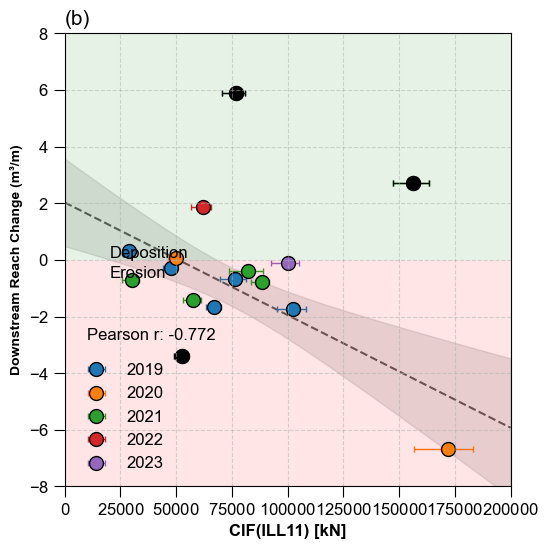

In [25]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
cache = {}
x_2019, y_2019 = df2.iloc[0:5]['CIF'].values, df1[df1.Year == 2019]['Erosion2'].values
x_err_2019 = df2.iloc[0:5][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2020, y_2020 = df2.iloc[5:7]['CIF'].values, df1[df1.Year == 2020]['Erosion2'].values
x_err_2020 = df2.iloc[5:7][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2021, y_2021 = df2.iloc[7:12]['CIF'].values, df1[df1.Year == 2021]['Erosion2'].values
x_err_2021 = df2.iloc[7:12][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2022, y_2022 = df2.iloc[12:13]['CIF'].values, df1[df1.Year == 2022]['Erosion2'].values
x_err_2022 = df2.iloc[12:13][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2023, y_2023 = df2.iloc[13:]['CIF'].values, df1[df1.Year == 2023]['Erosion2'].values
x_err_2023 = df2.iloc[13:][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T

cache.update({
    "x_2019": x_2019, "y_2019": y_2019, "x_err_2019": x_err_2019,
    "x_2020": x_2020, "y_2020": y_2020, "x_err_2020": x_err_2020,
    "x_2021": x_2021, "y_2021": y_2021, "x_err_2021": x_err_2021,
    "x_2022": x_2022, "y_2022": y_2022, "x_err_2022": x_err_2022,
    "x_2023": x_2023, "y_2023": y_2023, "x_err_2023": x_err_2023,
})


ax.errorbar(
    x=x_2019,
    y=y_2019,
    xerr=x_err_2019,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C0",
    mfc="C0",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2019",
    zorder=1
)
ax.errorbar(
    x=x_2020,
    y=y_2020,
    xerr=x_err_2020,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C1",
    mfc="C1",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2020",
    zorder=1
)
ax.errorbar(
    x=x_2021,
    y=y_2021,
    xerr=x_err_2021,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C2",
    mfc="C2",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2021",
    zorder=1
)
ax.errorbar(
    x=x_2022,
    y=y_2022,
    xerr=x_err_2022,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C3",
    mfc="C3",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2022",
    zorder=1
)
ax.errorbar(
    x=x_2023,
    y=y_2023,
    xerr=x_err_2023,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C4",
    mfc="C4",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2023",
    zorder=1
)

# labs = np.concatenate([
#     np.array(julday_list_2019),
#     np.array(julday_list_2020_12)[-2:],
#     np.array(julday_list_2021_12)[[2,4,5]],
#     np.array(julday_list_2022_12)[0:1]
# ])
x = np.concatenate([
    x_2019, x_2020, x_2021, x_2022, x_2023
])
y = np.concatenate([
    y_2019, y_2020, y_2021, y_2022, y_2023
])
x_err = np.concatenate([
    x_err_2019,
    x_err_2020,
    x_err_2021,
    x_err_2022,
    x_err_2023
], axis=1)
cache['x'] = x
cache['y'] = y
cache['x_err'] = x_err
# outlier
# ax.errorbar(
#     x=x_2019[2],
#     y=y_2019[2],
#     xerr=diff_2019[2:3,1:3].T,
#     yerr=None,
#     capsize=2,
#     ls='none',
#     elinewidth=1,
#     color="k",
#     mfc="k",
#     marker="o",
#     markeredgecolor="k",
#     markersize=10,
#     label=f"Outlier",
#     zorder=1
# )
ax.errorbar(
    x=x_2021[2],
    y=y_2021[2],
    xerr=x_err_2021[:,2:3],
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    zorder=1
)
ax.errorbar(
    x=x_2023[[-3, -1]],
    y=y_2023[[-3, -1]],
    xerr=x_err_2023[:,[-3,-1]],
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    zorder=1
)
cache['outlier_x'] = np.array([x_2021[2], *x_2023[[-3, -1]]])
cache['outlier_y'] = np.array([y_2021[2], *y_2023[[-3, -1]]])

sel_x, sel_y = x[[0,1,2,3,4,5,6,7,8,10,11,12,14]], y[[0,1,2,3,4,5,6,7,8,10,11,12,14]]
sel_x_err = x_err[:,[0,1,2,3,4,5,6,7,8,10,11,12,14]]
cache['sel_x'] = sel_x
cache['sel_y'] = sel_y
cache['sel_x_err'] = sel_x_err

def linear_func(beta, x):
    return beta[0] * x + beta[1]

sel_x_err_mean = sel_x_err.mean(axis=0)

data = RealData(sel_x, sel_y, sx=sel_x_err_mean)
model = Model(linear_func)
odr_inst = ODR(data, model, beta0=[-0.001, 3.0])
output = odr_inst.run()

slope, intercept = output.beta
slope_err, intercept_err = output.sd_beta

# Calculate prediction line and confidence interval
plot_x = np.linspace(0, 200_000, 1000)
y_pred = slope * plot_x + intercept

# Calculate confidence interval
residuals = sel_y - (slope * sel_x + intercept)
residual_std = np.std(residuals, ddof=1)
mean_sel_x = np.mean(sel_x)
sxx = np.sum((sel_x - mean_sel_x) ** 2)
t_val = 1.96

y_ci = t_val * residual_std * np.sqrt(1 / len(sel_x) + (plot_x - mean_sel_x) ** 2 / sxx)
y_lower = y_pred - y_ci
y_upper = y_pred + y_ci

ax.fill_between(plot_x, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)
ax.plot(plot_x, slope * plot_x + intercept, linestyle="--", color="k", alpha=0.6, zorder=0)

r2_log = r2_score(sel_y, linear_function([slope, intercept], sel_x))
corr_log, _ = stats.pearsonr(sel_x, sel_y)

info_text = (
    f"Pearson r: {corr_log:.3f}"
)
ax.text(0.05, 0.35, info_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.text(20000, 0.5, "Deposition", fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))
ax.text(20000, -0.2, "Erosion", fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

leg=ax.legend(loc="lower left", fontsize=12)

# ax.plot(sel_x, sel_y, "k.")
# i = 9
# ax.plot(x[i], y[i], "ro")
if leg:
    leg.get_frame().set_alpha(0)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("CIF(ILL11) [kN]", fontsize=12, fontweight="bold")
ax.set_ylabel('Downstream Reach Change (m³/m)', fontsize=10,fontweight="bold")
ax.set_xlim(0, 200_000)
ax.set_ylim(-8, 8)
ax.tick_params(axis='both', which='major', labelsize=12, length=8)
ax.axhspan(0, 8, facecolor='green', alpha=0.1)
ax.axhspan(-8, 0, facecolor='red', alpha=0.1)
ax.set_title("(b)", loc="left", fontsize=15) 
fig.tight_layout()
np.savez(f"{cache_path}/fig2.npz", **cache)
# fig.savefig(f"./output_images27/CIF-Erosion2-{interval_seconds}.png", dpi=600, transparent=False)

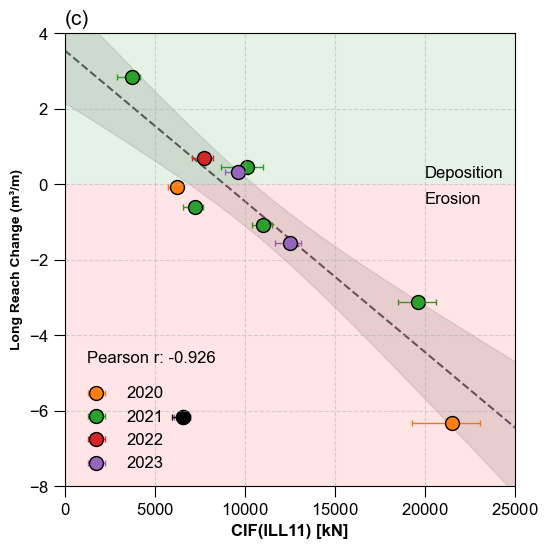

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

x_2020, y_2020 = df2.iloc[5:7]['CIF'].values, df1[df1.Year == 2020]['Erosion3'].values
x_err_2020 = df2.iloc[5:7][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2021, y_2021 = df2.iloc[7:12]['CIF'].values, df1[df1.Year == 2021]['Erosion3'].values
x_err_2021 = df2.iloc[7:12][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2022, y_2022 = df2.iloc[12:13]['CIF'].values, df1[df1.Year == 2022]['Erosion3'].values
x_err_2022 = df2.iloc[12:13][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T
x_2023, y_2023 = df2.iloc[13:]['CIF'].values, df1[df1.Year == 2023]['Erosion3'].values
x_err_2023 = df2.iloc[13:][['Neg_Err_CIF', 'Pos_Err_CIF']].values.T

# ax.errorbar(
#     x=x_2019,
#     y=y_2019,
#     xerr=x_err_2019,
#     yerr=None,
#     capsize=2,
#     ls='none',
#     elinewidth=1,
#     color="C0",
#     mfc="C0",
#     marker="o",
#     markeredgecolor="k",
#     markersize=10,
#     label=f"2019",
#     zorder=1
# )
ax.errorbar(
    x=x_2020,
    y=y_2020,
    xerr=x_err_2020,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C1",
    mfc="C1",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2020",
    zorder=1
)
ax.errorbar(
    x=x_2021,
    y=y_2021,
    xerr=x_err_2021,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C2",
    mfc="C2",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2021",
    zorder=1
)
ax.errorbar(
    x=x_2022,
    y=y_2022,
    xerr=x_err_2022,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C3",
    mfc="C3",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2022",
    zorder=1
)
ax.errorbar(
    x=x_2023,
    y=y_2023,
    xerr=x_err_2023,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="C4",
    mfc="C4",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    label=f"2023",
    zorder=1
)

# labs = np.concatenate([
#     np.array(julday_list_2019),
#     np.array(julday_list_2020_12)[-2:],
#     np.array(julday_list_2021_12)[[2,4,5]],
#     np.array(julday_list_2022_12)[0:1]
# ])
x = np.concatenate([
    x_2020, x_2021, x_2022, x_2023
])
y = np.concatenate([
    y_2020, y_2021, y_2022, y_2023
])
x_err = np.concatenate([
    x_err_2020,
    x_err_2021,
    x_err_2022,
    x_err_2023
], axis=1)
# outlier
# ax.errorbar(
#     x=x_2019[2],
#     y=y_2019[2],
#     xerr=diff_2019[2:3,1:3].T,
#     yerr=None,
#     capsize=2,
#     ls='none',
#     elinewidth=1,
#     color="k",
#     mfc="k",
#     marker="o",
#     markeredgecolor="k",
#     markersize=10,
#     label=f"Outlier",
#     zorder=1
# )
# ax.errorbar(
#     x=x_2021[2],
#     y=y_2021[2],
#     xerr=diff_2019[2:3,1:3].T,
#     yerr=None,
#     capsize=2,
#     ls='none',
#     elinewidth=1,
#     color="k",
#     mfc="k",
#     marker="o",
#     markeredgecolor="k",
#     markersize=10,
#     zorder=1
# )
ax.errorbar(
    x=x_2023[-1],
    y=y_2023[-1],
    xerr=x_err_2023[-1:,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markeredgecolor="k",
    markersize=10,
    zorder=1
)


sel_x, sel_y = x[[0,1,2,3,4,5,6,7,8]], y[[0,1,2,3,4,5,6,7,8]]
sel_x_err = x_err[:,[0,1,2,3,4,5,6,7,8]]

def linear_func(beta, x):
    return beta[0] * x + beta[1]

sel_x_err_mean = sel_x_err.mean(axis=0)

data = RealData(sel_x, sel_y, sx=sel_x_err_mean)
model = Model(linear_func)
odr_inst = ODR(data, model, beta0=[-0.001, 3.0])
output = odr_inst.run()

slope, intercept = output.beta
slope_err, intercept_err = output.sd_beta

# Calculate prediction line and confidence interval
plot_x = np.linspace(0, 25000, 100)
y_pred = slope * plot_x + intercept

# Calculate confidence interval
residuals = sel_y - (slope * sel_x + intercept)
residual_std = np.std(residuals, ddof=1)
mean_sel_x = np.mean(sel_x)
sxx = np.sum((sel_x - mean_sel_x) ** 2)
t_val = 1.96

y_ci = t_val * residual_std * np.sqrt(1 / len(sel_x) + (plot_x - mean_sel_x) ** 2 / sxx)
y_lower = y_pred - y_ci
y_upper = y_pred + y_ci

ax.fill_between(plot_x, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)
ax.plot(plot_x, slope * plot_x + intercept, linestyle="--", color="k", alpha=0.6, zorder=0)

r2_log = r2_score(sel_y, linear_function([slope, intercept], sel_x))
corr_log, _ = stats.pearsonr(sel_x, sel_y)

info_text = (
    f"Pearson r: {corr_log:.3f}"
)
ax.text(0.05, 0.3, info_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.text(20000, 0.5, "Deposition", fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))
ax.text(20000, -0.2, "Erosion", fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

leg=ax.legend(loc="lower left", fontsize=12)

# ax.plot(sel_x, sel_y, "k.")
# i = -1
# ax.plot(x[i], y[i], "ro")
if leg:
    leg.get_frame().set_alpha(0)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("CIF(ILL11) [kN]", fontsize=12, fontweight="bold")
ax.set_ylabel('Long Reach Change (m³/m)', fontsize=10,fontweight="bold")
ax.set_xlim(0, 25000)
ax.set_ylim(-8, 4)
ax.tick_params(axis='both', which='major', labelsize=12, length=8)
ax.axhspan(0, 4, facecolor='green', alpha=0.1)
ax.axhspan(-8, 0, facecolor='red', alpha=0.1)
ax.set_title("(c)", loc="left", fontsize=15) 
fig.tight_layout()
fig.savefig(f"./output_images27/CIF-Erosion3-{interval_seconds}.png", dpi=600, transparent=False)

In [20]:
0.92 ** 2

0.8464